# **Lab Exercise: Exploring Neural Information Processing**


## **Part 1: Biological Neural Response**
### **Step 1: Understanding Action Potentials**
Let's start by understanding how biological neurons communicate. Neurons use electrical signals called action potentials to transmit information. To grasp this concept, research the following key aspects of action potentials using online resources, textbooks, or Wolfram Alpha:

Resting membrane potential: The neuron's stable voltage when it's not actively signaling.
Threshold potential: The voltage that must be reached to trigger an action potential.
Depolarization and repolarization: The rapid changes in membrane potential during an action potential.
Refractory period: The brief period after an action potential when the neuron is less likely to fire again.
All-or-none principle: The idea that an action potential either happens completely or not at all.

### **Step 2: Simulating a Biological Neuron**

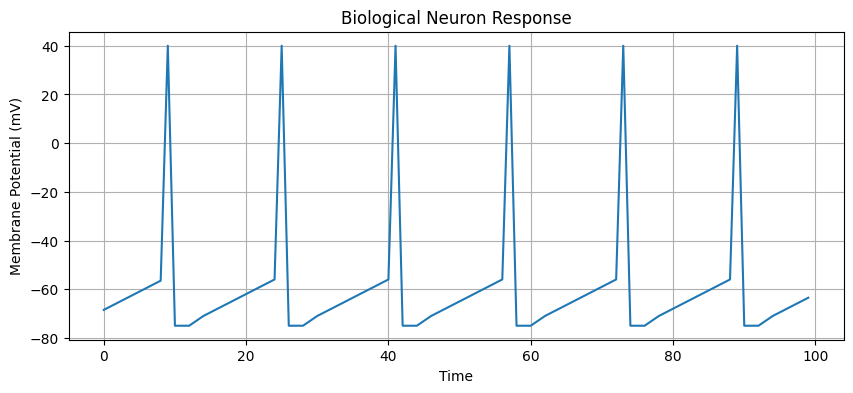

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class BiologicalNeuron:
    """Simulates basic biological neuron characteristics"""
    def __init__(self):
        self.resting_potential = -70  # mV
        self.threshold = -55          # mV
        self.reset_potential = -75    # mV

    def simulate_response(self, input_current):
        membrane_potential = self.resting_potential
        time_steps = 100
        membrane_potentials = []
        refractory_timer = 0

        for t in range(time_steps):
            if refractory_timer > 0:
                membrane_potential = self.reset_potential
                refractory_timer -= 1
            else:
                membrane_potential += input_current

                if membrane_potential >= self.threshold:
                    membrane_potentials.append(40)   # spike peak
                    membrane_potential = self.reset_potential
                    refractory_timer = 3
                    continue

                # small decay toward resting potential
                if membrane_potential > self.resting_potential:
                    membrane_potential -= 0.5

            membrane_potentials.append(membrane_potential)

        plt.figure(figsize=(10, 4))
        plt.plot(membrane_potentials)
        plt.xlabel("Time")
        plt.ylabel("Membrane Potential (mV)")
        plt.title("Biological Neuron Response")
        plt.grid(True)
        plt.show()

# Example usage
neuron = BiologicalNeuron()
neuron.simulate_response(2)

### **Step 3: Analyzing the Response**
Experiment with different input currents in your code to observe how the neuron's membrane potential changes over time. Analyze the following:

- How does the input current affect the generation of action potentials?

- What happens when the input current is below the threshold?

- How does the neuron's response change with varying input current strengths?


Input Current = 0.2


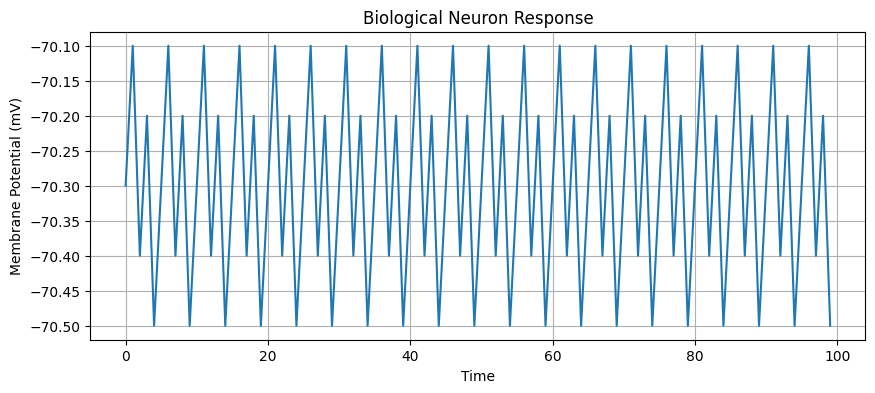


Input Current = 0.5


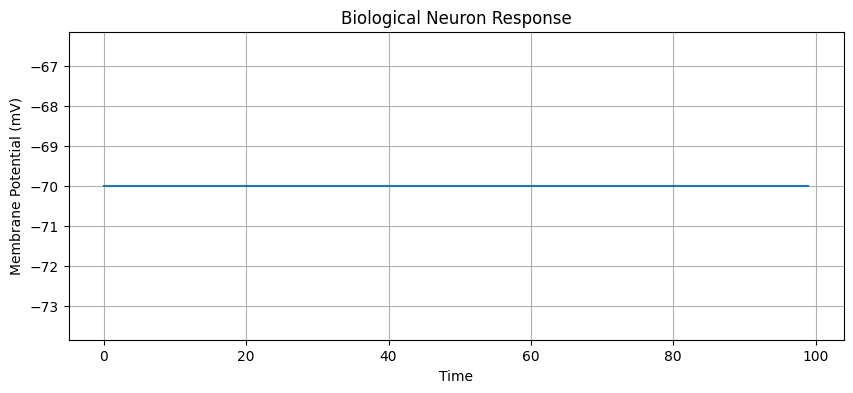


Input Current = 1


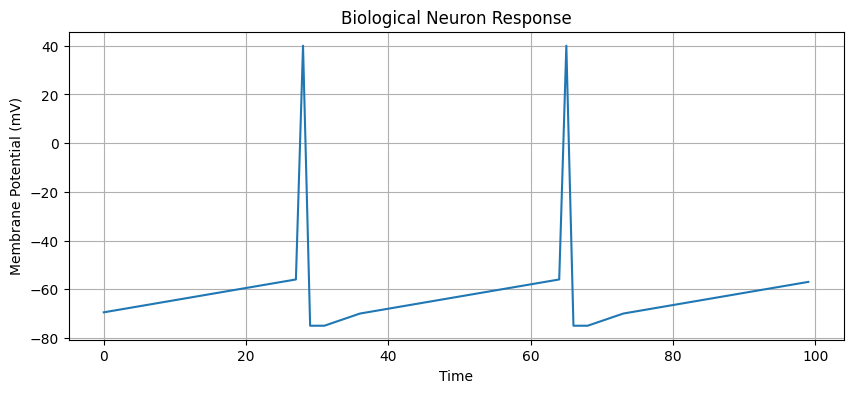


Input Current = 2


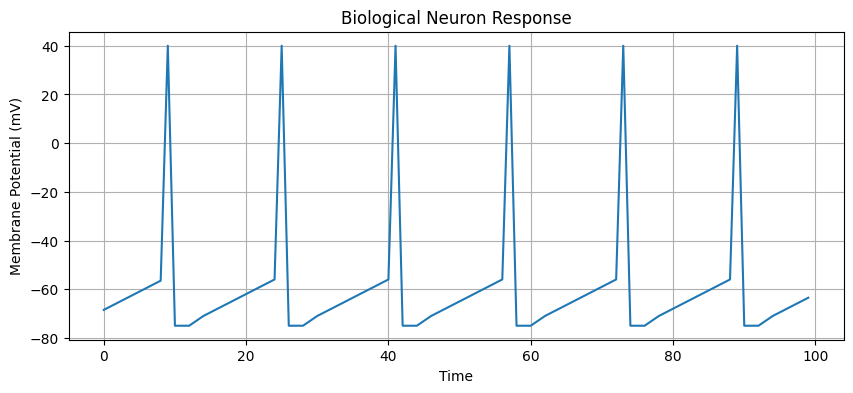

In [2]:
neuron = BiologicalNeuron()

# Try different input currents
currents = [0.2, 0.5, 1, 2]

for current in currents:
    print(f"\nInput Current = {current}")
    neuron.simulate_response(current)

**Analysis:**

1. How does the input current affect the generation of action potentials?

The input current directly affects whether and how quickly action potentials are generated. As the input current increases, the membrane potential rises more rapidly and reaches the threshold sooner, leading to earlier and more frequent spikes. Lower input currents cause a slower increase in membrane potential, resulting in delayed or less frequent action potentials.

2. What happens when the input current is below the threshold?

When the input current is below the threshold, the neuron may not immediately generate an action potential. However, in this simplified model, the membrane potential gradually accumulates over time, which can eventually cause it to reach the threshold and produce spikes. In real biological neurons, weak inputs typically do not trigger action potentials due to natural leakage and resistance, but this effect is not fully captured in the model.

3. How does the neuron's response change with varying input current strengths?

As the input current increases, the neuron responds more quickly and more actively. Higher input currents cause the membrane potential to rise faster, resulting in more frequent and earlier spikes. In contrast, lower input currents produce slower responses and fewer spikes over time. This demonstrates that stronger inputs lead to a stronger and faster neuronal response.

## **Part 2: Artificial Neuron Implementation**

### **Step 1: Building an Artificial Neuron**

Now, let's turn our attention to artificial neurons. These are the building blocks of artificial neural networks.

In [3]:
import numpy as np

class ArtificialNeuron:
    """Implements artificial neuron for comparison"""

    def __init__(self, num_inputs):
        # Initialize weights randomly
        self.weights = np.random.randn(num_inputs)
        self.bias = 0

    def activate(self, inputs):
        """Implements artificial neuron activation"""
        # Calculate weighted sum
        weighted_sum = np.dot(self.weights, inputs) + self.bias

        # Sigmoid activation function
        output = 1 / (1 + np.exp(-weighted_sum))

        return output


# Example usage
neuron = ArtificialNeuron(3)

inputs = np.array([0.5, 0.2, 0.8])
output = neuron.activate(inputs)

print("Weights:", neuron.weights)
print("Output:", output)

Weights: [1.01304461 0.1638747  0.53591346]
Output: 0.7247262648166205


### **Step 2: Exploring Activation Functions**

Experiment with different activation functions in your code.

Python:

- Sigmoid: output = 1 / (1 + np.exp(-weighted_sum))

- ReLU (Rectified Linear Unit): output = max(0, weighted_sum)

- tanh (hyperbolic tangent): output = np.tanh(weighted_sum)

In [4]:
class ArtificialNeuron:
    def __init__(self, num_inputs):
        self.weights = np.random.randn(num_inputs)
        self.bias = 0

    def activate(self, inputs, function_type="sigmoid"):
        weighted_sum = np.dot(self.weights, inputs) + self.bias

        if function_type == "sigmoid":
            output = 1 / (1 + np.exp(-weighted_sum))
        elif function_type == "relu":
            output = max(0, weighted_sum)
        elif function_type == "tanh":
            output = np.tanh(weighted_sum)
        else:
            raise ValueError("Unknown activation function")

        return weighted_sum, output

In [5]:
neuron = ArtificialNeuron(3)
inputs = np.array([0.5, 0.2, 0.8])

for func in ["sigmoid", "relu", "tanh"]:
    z, out = neuron.activate(inputs, func)
    print(f"{func.upper()} -> z: {z:.2f}, output: {out:.2f}")

SIGMOID -> z: 0.32, output: 0.58
RELU -> z: 0.32, output: 0.32
TANH -> z: 0.32, output: 0.31


**Analyze how each activation function affects the neuron's output.**

Different activation functions affect how the artificial neuron transforms the weighted sum into an output.

The sigmoid function produces outputs between 0 and 1. It smoothly compresses the weighted sum into a probability-like value. For example, when the input is large and positive, the output approaches 1, and when the input is large and negative, the output approaches 0. This makes sigmoid useful for representing probabilities, but it can reduce sensitivity to large input changes.

The Rectified Linear Unit (ReLU) outputs 0 for negative or zero inputs and increases linearly for positive inputs. This means the neuron only activates when the weighted sum is positive. ReLU is simple and efficient, and it allows strong signals to pass through without compression. However, it ignores all negative inputs, which can cause some neurons to become inactive.

The hyperbolic tangent (tanh) function produces outputs between -1 and 1. It is centered around zero, meaning it can represent both positive and negative signals. Compared to sigmoid, tanh provides a more balanced output, which can help improve learning in neural networks.

Overall, activation functions determine how strongly a neuron responds to input and influence how information is processed in artificial neural networks.

### **Step 3: Comparing with Biological Neurons**

Compare the behavior of the artificial neuron with the biological neuron model you implemented earlier. Consider the following:

**1. How do the input-output relationships differ between the two models?**

The biological neuron processes input over time, where the membrane potential gradually changes based on input current. When the potential reaches a threshold, it generates an action potential (spike). This creates a time-dependent and dynamic input-output relationship.

In contrast, the artificial neuron produces an output instantly by calculating a weighted sum of inputs and applying an activation function. The output is continuous and does not depend on time. Therefore, the biological neuron has a dynamic, time-based response, while the artificial neuron has a static, immediate response.

**2. What are the key distinctions in information processing between biological and artificial neurons?**

Biological neurons process information through electrical signals that evolve over time and include features such as spikes, refractory periods, and temporal integration. Their communication is discrete and influenced by past activity.

Artificial neurons process information mathematically using weighted sums and activation functions. They do not model time, memory, or biological processes directly. Instead, they focus on efficient computation and learning patterns from data.

**3. How do the concepts of threshold and activation function relate to each other?**

The threshold in biological neurons determines whether an action potential will occur. If the membrane potential reaches the threshold, the neuron fires; otherwise, it does not. This follows the all-or-none principle.

In artificial neurons, activation functions play a similar role by controlling how the weighted input is transformed into an output. Some activation functions, such as ReLU, behave like a threshold by outputting zero for negative inputs and positive values otherwise. Other functions, like sigmoid and tanh, provide smoother transitions instead of a sharp threshold.

## **Part 3: Information Integration Study**

### **Step 1: Creating Simple Networks**
Construct simple networks of both biological and artificial neurons using the models you implemented in Parts 1 and 2. Connect these neurons in different configurations (e.g., feedforward, recurrent) to explore how information flows through the network.

**Part A — Artificial Neuron Network**

1. Feedforward Network

In [6]:
# Create 2 artificial neurons
neuron1 = ArtificialNeuron(3)
neuron2 = ArtificialNeuron(1)

# Input layer
inputs = np.array([0.5, 0.2, 0.8])

# Forward pass
z1, out1 = neuron1.activate(inputs, "sigmoid")

# Output of neuron1 becomes input to neuron2
z2, out2 = neuron2.activate(np.array([out1]), "sigmoid")

print("Neuron 1 output:", out1)
print("Neuron 2 output:", out2)

Neuron 1 output: 0.2627975789274701
Neuron 2 output: 0.38617259236615903


2. Recurrent Network

In [7]:
neuron = ArtificialNeuron(1)

input_value = 0.5
state = 0

outputs = []

for t in range(10):
    z, state = neuron.activate(np.array([input_value + state]), "tanh")
    outputs.append(state)

print(outputs)

[np.float64(-0.31017717506350795), np.float64(-0.12116980050071972), np.float64(-0.23833970480901415), np.float64(-0.1662918293248915), np.float64(-0.21085701989005465), np.float64(-0.1833821143633651), np.float64(-0.20035747223203168), np.float64(-0.18988276611195495), np.float64(-0.19635149080546105), np.float64(-0.19235866678525748)]


Recurrent Output Plot

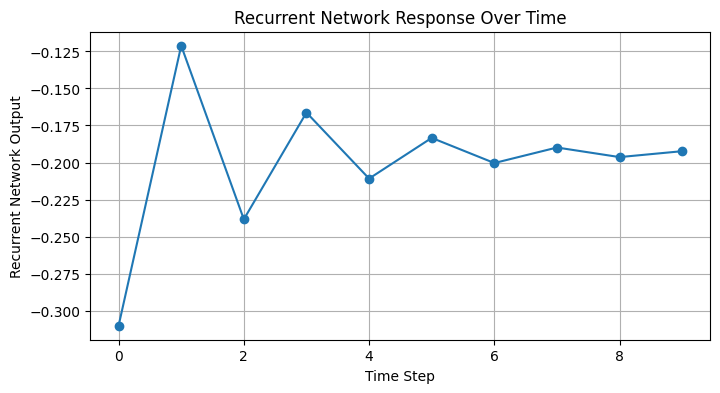

In [8]:
plt.figure(figsize=(8,4))
plt.plot(outputs, marker='o')
plt.xlabel("Time Step")
plt.ylabel("Recurrent Network Output")
plt.title("Recurrent Network Response Over Time")
plt.grid(True)
plt.show()

**Part B — Biological Network**

Neuron 1 response:


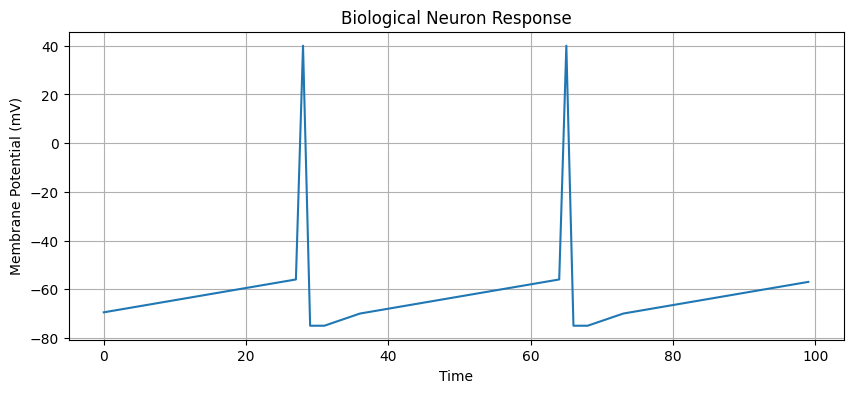

Neuron 2 response:


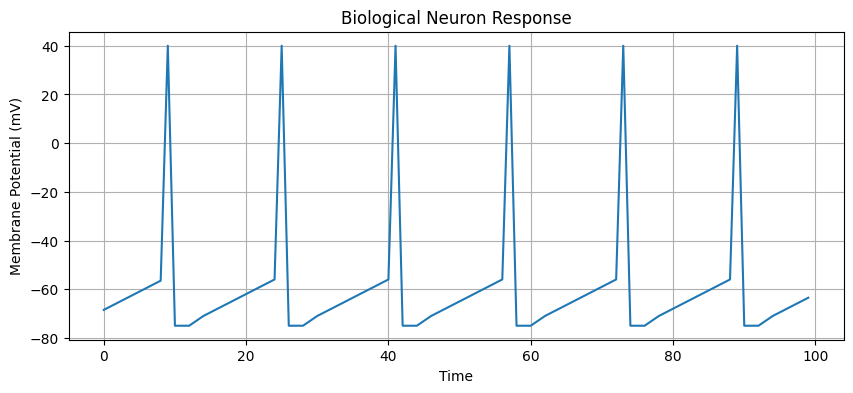

In [9]:
neuron1 = BiologicalNeuron()
neuron2 = BiologicalNeuron()

# Simulate neuron 1
print("Neuron 1 response:")
neuron1.simulate_response(1)

# Simulate neuron 2 using stronger input
print("Neuron 2 response:")
neuron2.simulate_response(2)

### **Step 2: Analyzing Network Behavior**

Provide different input patterns to your networks and observe how the networks process and integrate information. Analyze the following:

**1. How do the networks respond to different input combinations?**

The networks respond differently depending on the input values. In the feedforward network, different input combinations produce different outputs because the inputs are combined using weights and passed through activation functions. Small changes in input can lead to different outputs, showing that the network is sensitive to input variations.

In the recurrent network, the response depends not only on the current input but also on previous outputs. As a result, the output changes over time and may gradually stabilize. This demonstrates that recurrent networks integrate information across multiple time steps, allowing them to reflect past inputs in their current response.

**2. How does the network architecture affect the output?**

The architecture of the network plays a key role in how information is processed. In a feedforward network, information flows in one direction from input to output, and each neuron processes the input independently at each step. This results in a straightforward transformation of the input.

In contrast, the recurrent network includes feedback connections, where outputs are fed back into the network. This creates a dependency on previous states and introduces a form of memory. As a result, the output evolves over time rather than being computed in a single step.

**3. What are the limitations of these simple networks in processing complex information?**

These simple networks have several limitations. First, they contain very few neurons and layers, which restricts their ability to learn complex patterns. Second, they use fixed or randomly initialized weights without any training, so they cannot adapt or improve their performance.

Additionally, the biological neuron model is highly simplified and does not capture many important features of real neurons, such as detailed ion channel behavior or realistic spike timing. The artificial networks also lack depth and advanced structures found in modern neural networks.

Overall, these simple networks can demonstrate basic information processing but are not sufficient for handling complex tasks such as image recognition or natural language processing.